### 0. Importing PyTorch and setting device-agnostic code 

In [1]:
import torch
from torch import nn

In [2]:
# Setup device-agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### 1. Get data

In [3]:
from pathlib import Path

In [4]:
data_dir = Path("chest_xray")

In [5]:
train_dir = data_dir / "train"
test_dir = data_dir / "test"
val_dir = data_dir / "val"

print(train_dir)
print(test_dir)
print(val_dir)

chest_xray\train
chest_xray\test
chest_xray\val


### 1.1 Visualizing an image

1. Get all of the image paths
2. Pick a random image using Python's random.choice()
3. Get image class using pathlib.Path.parent.stem
4. Since, I am working with images, let's open the image with Python's PIL
5. I'll then show the image and print metadata

In [6]:
import random
from PIL import Image

Image class: PNEUMONIA
Image height: 763
Image width: 1430


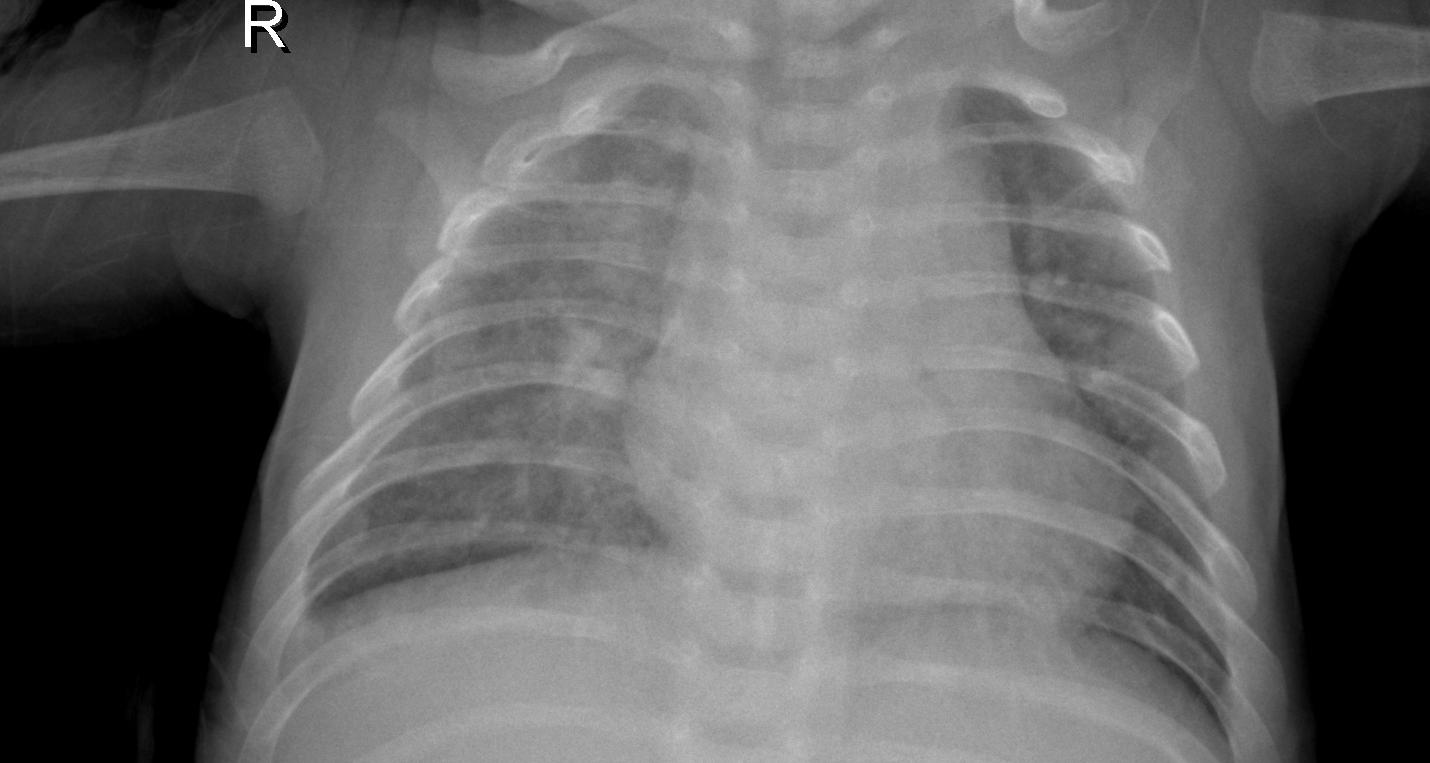

In [7]:
# 1. Getting all the image path 
image_path_list = list(data_dir.glob("*/*/*.jpeg"))
image_path_list

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get the image class from path name(the image class is the name of the directory where the the image is saved)
image_class = random_image_path.parent.stem

# 4. Open the image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

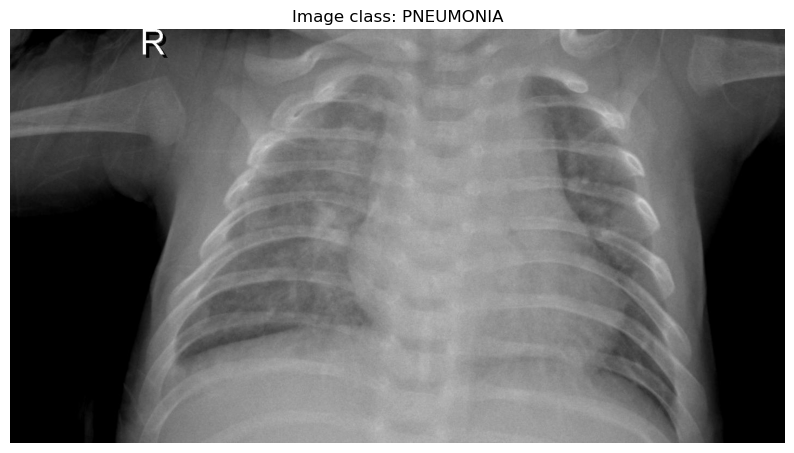

In [8]:
# Visualize with matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Truning image into nparray
img_as_array = np.array(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array, cmap= "gray")
plt.title(f"Image class: {image_class}")
plt.axis(False)
plt.show()


### 2. Making data ready

#### 2.1 Cheking the train and validation split

In [9]:
for split in [train_dir, test_dir, val_dir]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = split / cls
        n = len(list(folder.glob("*.jpeg")))
        print(split.name, cls, n)

train NORMAL 1341
train PNEUMONIA 3875
test NORMAL 234
test PNEUMONIA 390
val NORMAL 8
val PNEUMONIA 8


#### 2.2 Creating new train and validation split (85% and 15%)

In [10]:
import shutil
import random

random.seed(42)

new_val_dir = Path("chest_xray/new_val")
new_train_dir = Path("chest_xray/new_train")

val_fraction = 0.15 # train and validation split is 85 - 15

for cls in ["NORMAL", "PNEUMONIA"]:
    src_folder = train_dir / cls
    images = list(src_folder.glob("*.jpeg"))
    random.shuffle(images)

    n_val = int(len(images) * val_fraction)
    val_images = images[:n_val]
    train_images = images[n_val:]

    (new_val_dir / cls).mkdir(parents=True, exist_ok=True)
    (new_train_dir / cls).mkdir(parents=True, exist_ok=True)

    for img in val_images:
        shutil.copy(img, new_val_dir / cls / img.name)
    for img in train_images:
        shutil.copy(img, new_train_dir / cls / img.name)

    print(cls, "train:", len(train_images), "val:", len(val_images))

NORMAL train: 1140 val: 201
PNEUMONIA train: 3294 val: 581


### 3. Transforming data

Before I can use our image data with PyTorch:

    1. I need to turn my data into tensors.
    2. Turn into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`. 

In [11]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### 3.1 Transforming data with `torchvision.transfor`

In [12]:
# transform for images
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size = (64,64)),
    transforms.ToTensor()
])

#### 3.2 plotting different images after transform

In [13]:
def plot_transformed_images(image_path: list, transform, n= 3):
    """
    Selects random images from a path of images and transforms them
    then plots the original vs transformed version.
    """
    random_image_path = random.sample(image_path, k = n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            # Plotting Original Images
            fig, ax = plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f, cmap = "gray")
            ax[0].set_title(f"Originl\nSize: {f.size}")
            ax[0].axis(False)

            # Plotting Main Images
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image, cmap = "gray")
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize = 16)



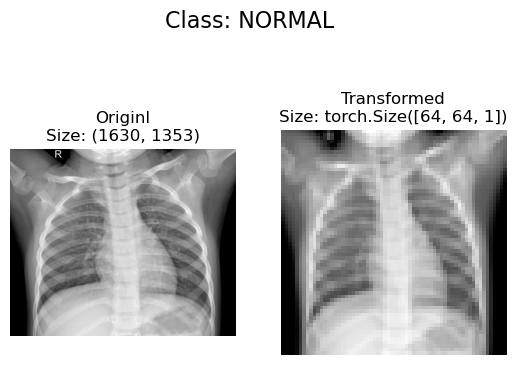

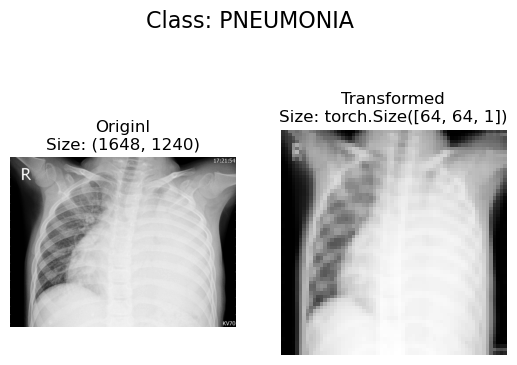

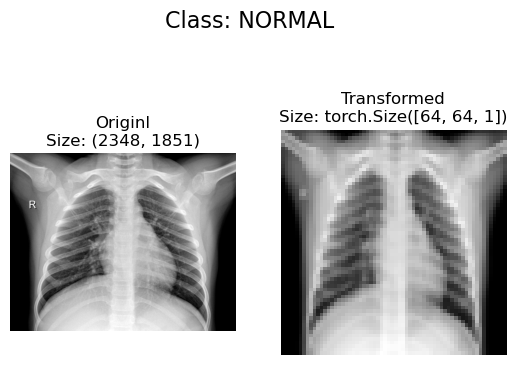

In [14]:
plot_transformed_images(image_path= image_path_list,
                        transform= data_transform,
                        n = 3)

### 4. Loading images using `ImageFolder`

I will be loading the image classification data using `torchvision.datasets.ImageFolder`

In [15]:
from torchvision import datasets
train_data = datasets.ImageFolder(root= new_train_dir,
                                  transform= data_transform,
                                  target_transform= None)
validation_data = datasets.ImageFolder(root = new_val_dir,
                                       transform= data_transform,
                                       target_transform= None)

test_data = datasets.ImageFolder(root = test_dir,
                                 transform= data_transform)

In [16]:
train_data, test_data, validation_data

(Dataset ImageFolder
     Number of datapoints: 4434
     Root location: chest_xray\new_train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 624
     Root location: chest_xray\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 782
     Root location: chest_xray\new_val
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [17]:
# Get the class names 
class_names = train_data.classes
class_names

['NORMAL', 'PNEUMONIA']

In [18]:
# Get the class names as dict
class_dict = train_data.class_to_idx
class_dict

{'NORMAL': 0, 'PNEUMONIA': 1}

In [19]:
# checking the length of train and validation 
len(train_data), len(validation_data)

(4434, 782)

#### 4.1 Turning my loaded images into `DataLoader`s

A DataLoader is going to help my dataset into iterables and we can customise the `batch_size` so my model can see the `batch_size` images at a time.

In [20]:
import os 


In [21]:
# Turn train and test datasets into DataLoader'
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKER = os.cpu_count()

train_dataloader = DataLoader(dataset= train_data,
                              batch_size= BATCH_SIZE,
                              num_workers= NUM_WORKER,
                              shuffle= True)
validation_dataloader = DataLoader(dataset= validation_data,
                                   batch_size= BATCH_SIZE,
                                   num_workers= NUM_WORKER,
                                   shuffle= False)
test_dataloader = DataLoader(dataset= test_data,
                             batch_size= BATCH_SIZE,
                             num_workers= NUM_WORKER,
                             shuffle= False)

In [22]:
len(train_dataloader), len(validation_dataloader), len(test_dataloader)

(139, 25, 20)

In [23]:
img , label = next(iter(train_dataloader))
print(f"Image shape: {img.shape}")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


### 5. Mode 0 : TinyVGG model

Replicating TinyVGG architecture from CNN Explainer website 

#### 5.1 Creating TinyVGG model class

In [24]:
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from CNN Explainer.
    """
    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels= input_shape,
                      out_channels= hidden_units,
                      kernel_size= 3,
                      padding= 0,
                      stride = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units,
                      out_channels= hidden_units,
                      kernel_size= 3,
                      padding= 0,
                      stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2,
                         stride= 2)             
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels= hidden_units,
                      out_channels= hidden_units,
                      kernel_size= 3,
                      padding= 0,
                      stride = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units,
                                  out_channels= hidden_units,
                                  kernel_size= 3,
                                  padding= 0,
                                  stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2,
                         stride = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= hidden_units * 13* 13,
                      out_features= output_shape)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        #print(x.shape)
        x = self.conv_block2(x)
        #print(x.shape)
        x = self.classifier(x)
        return x

In [25]:
model_0 = TinyVGG(input_shape= 3,
                  hidden_units= 10,
                  output_shape= len(class_names))
model_0

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=2, bias=True)
  )
)

#### 5.2 Try a forward pass on a sing image (to test the model)

In [26]:
img.shape

torch.Size([32, 3, 64, 64])

In [27]:
# Get a single image
model_0(img)

tensor([[-0.0683,  0.0407],
        [-0.0774,  0.0507],
        [-0.0585,  0.0450],
        [-0.0696,  0.0529],
        [-0.0723,  0.0532],
        [-0.0848,  0.0527],
        [-0.0728,  0.0562],
        [-0.0745,  0.0492],
        [-0.0744,  0.0499],
        [-0.0773,  0.0536],
        [-0.0644,  0.0523],
        [-0.0856,  0.0511],
        [-0.0752,  0.0511],
        [-0.0657,  0.0543],
        [-0.0476,  0.0401],
        [-0.0684,  0.0435],
        [-0.0704,  0.0473],
        [-0.0825,  0.0555],
        [-0.0644,  0.0491],
        [-0.0886,  0.0451],
        [-0.0767,  0.0609],
        [-0.0742,  0.0630],
        [-0.0762,  0.0477],
        [-0.0739,  0.0525],
        [-0.0735,  0.0489],
        [-0.0699,  0.0534],
        [-0.0689,  0.0525],
        [-0.0710,  0.0469],
        [-0.0664,  0.0564],
        [-0.0820,  0.0427],
        [-0.0715,  0.0495],
        [-0.0606,  0.0479]], grad_fn=<AddmmBackward0>)

#### 5.3 Use `torch.info` to get an idea of the shapes going through our model

In [28]:
from torchinfo import summary

In [29]:
summary(model_0, input_size= [32,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 2]                   --
├─Sequential: 1-1                        [32, 10, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 10, 62, 62]          280
│    └─ReLU: 2-2                         [32, 10, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 10, 60, 60]          910
│    └─ReLU: 2-4                         [32, 10, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 10, 30, 30]          --
├─Sequential: 1-2                        [32, 10, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 10, 28, 28]          910
│    └─ReLU: 2-7                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 10, 26, 26]          910
│    └─ReLU: 2-9                         [32, 10, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 10, 13, 13]          --
├─Sequentia

#### 5.4 Creating train and test steps funtions 
* `train_step()` - takes a model and dataloader and trains the model on the DataLoader
* `test_step()` - takes a model and dataloader and test the model on the DataLoader

In [30]:
# Create train_step()

def train_step(model: torch.nn.Module,
               dataloder: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()
    train_loss, train_acc = 0,0
    # loop through the data batches
    for batch, (X,y) in enumerate(dataloder):
        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero frad
        optimizer.zero_grad()

        # 4. Loss backward 
        loss.backward()

        # 5. Optimizer step 
        optimizer.step()

        # Calculate accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloder)
    train_acc = train_acc / len(dataloder)
    return train_loss, train_acc 

In [31]:
# Create eval step

def eval_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

    # Put the model in eval mode
    model.eval()

    # Setup loss and accuracy values
    loss_total, acc_total = 0,0

    # Turn on inference mode 
    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            # 1. Forward pass 
            test_pred_logits = model(X)

            # 2. Calculate the loss
            loss = loss_fn(test_pred_logits, y)
            loss_total += loss.item()

            # Calculate the accuracy 
            test_pred_labels = test_pred_logits.argmax(dim = 1)
            acc_total += ((test_pred_labels == y).sum().item()/ len(test_pred_labels))

    loss_total = loss_total / len(dataloader)
    acc_total = acc_total / len(dataloader)
    return loss_total, acc_total



#### 5.5 Creating `train()` funtion to combine `train_step()` and `eval_step()`

In [32]:
from tqdm.auto import tqdm

# 1. Create a train funtion that takes in various model parameters + optimizer + dataloaders 

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int):
    # 2. Creating result dictionary 
    results = {
        "train_loss" : [],
        "train_acc" : [],
        "val_loss" : [],
        "val_acc" : []
    }
    # 3. Loop through training and eval step
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model_0, 
                                           dataloder= train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer= optimizer)
        val_loss, val_acc = eval_step(model = model_0, 
                                      dataloader= validation_dataloader,
                                      loss_fn= loss_fn)

        # 4. Print out what's happening
        print(f"Epoch : {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}% | Validation loss: {val_loss:.4f} | Validation acc: {val_acc:.4f}%")

        # 5. Update results dictionary 
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    return results

        

#### 5.6 Train and evaluate `model_0`

In [33]:
NUM_EPOCHS = 5

# Setup the loss funtion and optimizer 

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model_0.parameters(), lr = 0.001)

# Train the model_0
model_0_results = train(model = model_0,
                        train_dataloader= train_dataloader,
                        val_dataloader= validation_dataloader,
                        optimizer= optimizer,
                        loss_fn= loss_fn,
                        epochs= NUM_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 | Train loss: 0.4254 | Train acc: 0.8079% | Validation loss: 0.2603 | Validation acc: 0.8875%
Epoch : 1 | Train loss: 0.1707 | Train acc: 0.9344% | Validation loss: 0.1717 | Validation acc: 0.9437%
Epoch : 2 | Train loss: 0.1650 | Train acc: 0.9362% | Validation loss: 0.1634 | Validation acc: 0.9500%
Epoch : 3 | Train loss: 0.1428 | Train acc: 0.9432% | Validation loss: 0.1411 | Validation acc: 0.9437%
Epoch : 4 | Train loss: 0.1309 | Train acc: 0.9487% | Validation loss: 0.1337 | Validation acc: 0.9550%


In [35]:
test_loss, test_acc = eval_step(model=model_0,
                                 dataloader=test_dataloader,
                                 loss_fn=loss_fn,
                                 )
print(f"Final Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Final Test loss: 0.7001 | Test acc: 0.7578


#### 5.7 Plotting the loss curves for `model_0`

 A loss curve is a way of tracking my model's progression over time.

In [36]:
# Get the model_0 results key

model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])

In [38]:
def plot_loss_curves(results: dict[str, list[float]]):
    """Plots training and validation curves of the result dictionary"""
    train_loss = results["train_loss"]
    val_loss = results["val_loss"]

    train_acc = results["train_acc"]
    val_acc = results["val_acc"]

    # How many epochs there are 
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    # Plot both loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label = "Train Loss")
    plt.plot(epochs, val_loss, label = "Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot both accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label = "Train Accuracy")
    plt.plot(epochs, val_acc, label = "Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend() 

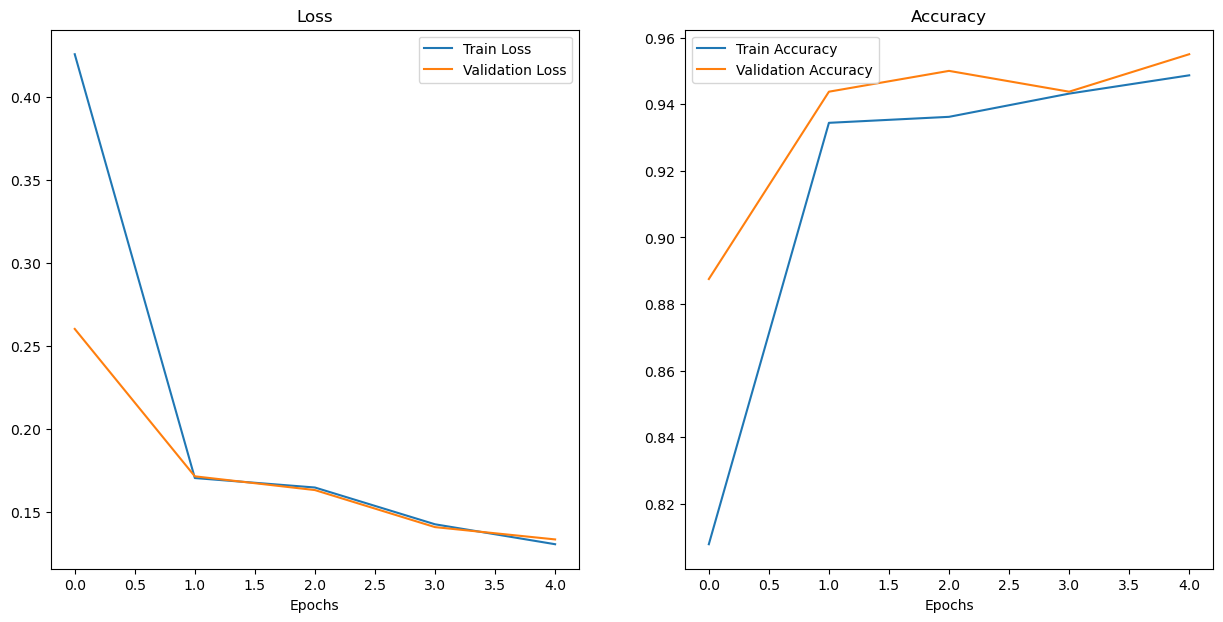

In [39]:
plot_loss_curves(results=model_0_results)

#### 5.8 Evaluating the model using other metrics

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

model_0.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for X,y in test_dataloader:
        logits = model_0(X)
        preds = logits.argmax(dim = 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 88 146]
 [  9 381]]
              precision    recall  f1-score   support

      NORMAL       0.91      0.38      0.53       234
   PNEUMONIA       0.72      0.98      0.83       390

    accuracy                           0.75       624
   macro avg       0.82      0.68      0.68       624
weighted avg       0.79      0.75      0.72       624

